# NLP Project: Extract frequent keywords from feedback

## Importing Required Libraries

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import string


from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob

## Loading the Dataset

In [115]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [116]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Amazon_Reviews.csv',
                 engine='python',
                 on_bad_lines='skip')

df.head()

,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


In [117]:
df.columns


Index(['Reviewer Name', 'Profile Link', 'Country', 'Review Count',
       'Review Date', 'Rating', 'Review Title', 'Review Text',
       'Date of Experience'],
      dtype='object')

## Data Selection and Cleaning

In [118]:
df = df[['Review Text']]
df = df.dropna()

df.head()

,Review Text
0,"I registered on the website, tried to order a ..."
1,Had multiple orders one turned up and driver h...
2,I informed these reprobates that I WOULD NOT B...
3,I have bought from Amazon before and no proble...
4,If I could give a lower rate I would! I cancel...


In [119]:
df = df.sample(5000, random_state=42)

## Text Preprocessing and Cleaning

In [120]:
CUSTOM_STOPWORDS = {
    'amazon','would','one','get',
    'even','could','also','us',
    'im','said'
}

stop_words = set(stopwords.words('english')) | CUSTOM_STOPWORDS

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = str(text).lower()

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
        and len(word) > 2
        and not word.isnumeric()
    ]

    return words

## Applying Text Cleaning and Preparing Data

In [121]:
df['cleaned'] = df['Review Text'].apply(clean_text)

df['Cleaned_Text'] = df['cleaned'].apply(
    lambda x: " ".join(x)
)

## Keyword Extraction using Frequency Analysis

In [122]:
all_words = []

for words in df['cleaned']:
    all_words.extend(words)

word_freq = Counter(all_words)

top_keywords = word_freq.most_common(20)


keywords_df = pd.DataFrame(top_keywords, columns=['Keyword', 'Frequency'])

keywords_df

,Keyword,Frequency
0,customer,2965
1,service,2812
2,item,2495
3,delivery,2072
4,time,1964
5,day,1939
6,order,1905
7,prime,1362
8,refund,1285
9,account,1258


## Visualization of Keyword Frequency

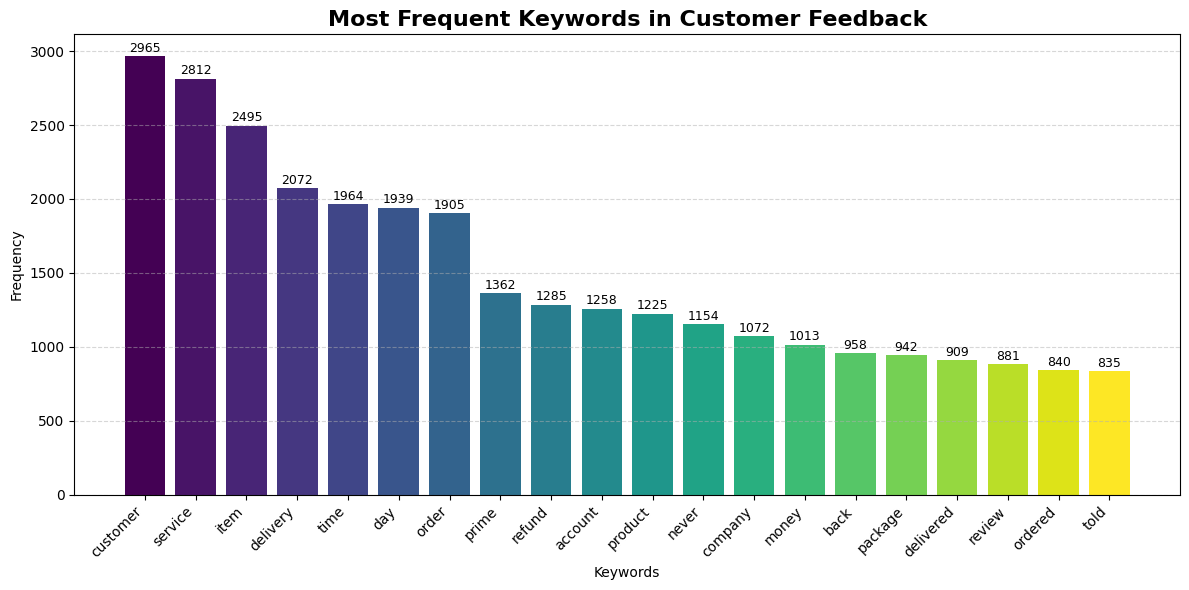

In [123]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,6))

colors = plt.cm.viridis(np.linspace(0, 1, len(keywords_df)))

bars = plt.bar(keywords_df['Keyword'], keywords_df['Frequency'], color=colors)

# Add labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval),
             ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=45, ha='right')
plt.title("Most Frequent Keywords in Customer Feedback", fontsize=16, fontweight='bold')
plt.xlabel("Keywords")
plt.ylabel("Frequency")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Word Cloud Representation of Keywords

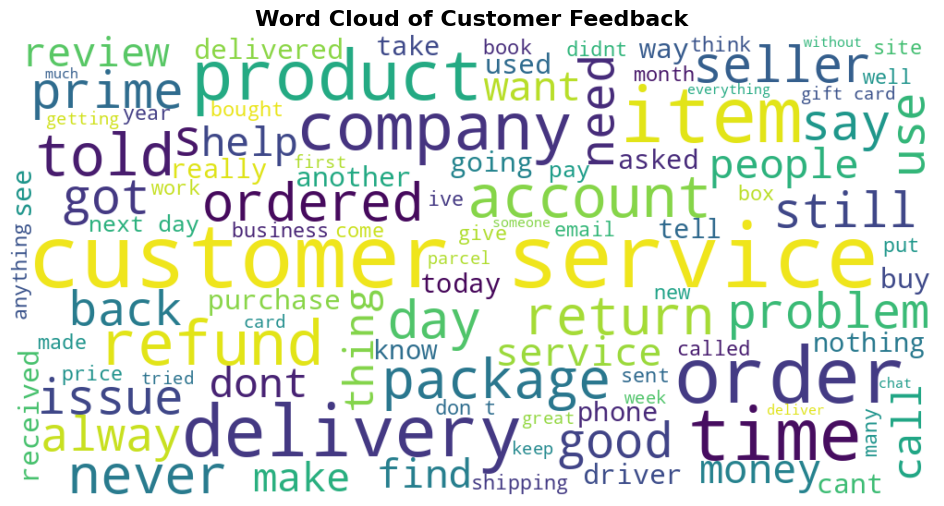

In [124]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

custom_stopwords = set(STOPWORDS)
custom_stopwords.update(['amazon','would','one','get','even','said','also','could'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=custom_stopwords,
    max_words=100,
    colormap='viridis',
    contour_width=1,
    contour_color='black'
).generate(" ".join(all_words))

# Plot
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Customer Feedback", fontsize=16, fontweight='bold')
plt.show()

## Keyword Extraction using TF-IDF

In [125]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_features=20)

X = vectorizer.fit_transform(df['Cleaned_Text'])

feature_names = vectorizer.get_feature_names_out()
scores = X.sum(axis=0).A1

tfidf_df = pd.DataFrame({'Keyword': feature_names, 'Score': scores})
tfidf_df = tfidf_df.sort_values(by='Score', ascending=False)

tfidf_df

,Keyword,Score
17,service,737.521166
2,customer,703.564856
7,item,574.295313
5,delivery,574.205571
18,time,514.239437
9,order,485.307286
3,day,457.582690
12,prime,417.509779
13,product,401.525420
1,company,376.763538


## Bigram Analysis (Phrase Extraction)

In [126]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english', ngram_range=(2,2), max_features=15)

X = vectorizer.fit_transform(df['Cleaned_Text'])

bigrams = vectorizer.get_feature_names_out()

print(bigrams)

['credit card' 'customer service' 'customer support' 'day delivery'
 'day later' 'delivery date' 'delivery driver' 'delivery time' 'gift card'
 'item delivered' 'ordered item' 'placed order' 'prime member'
 'prime membership' 'review text']


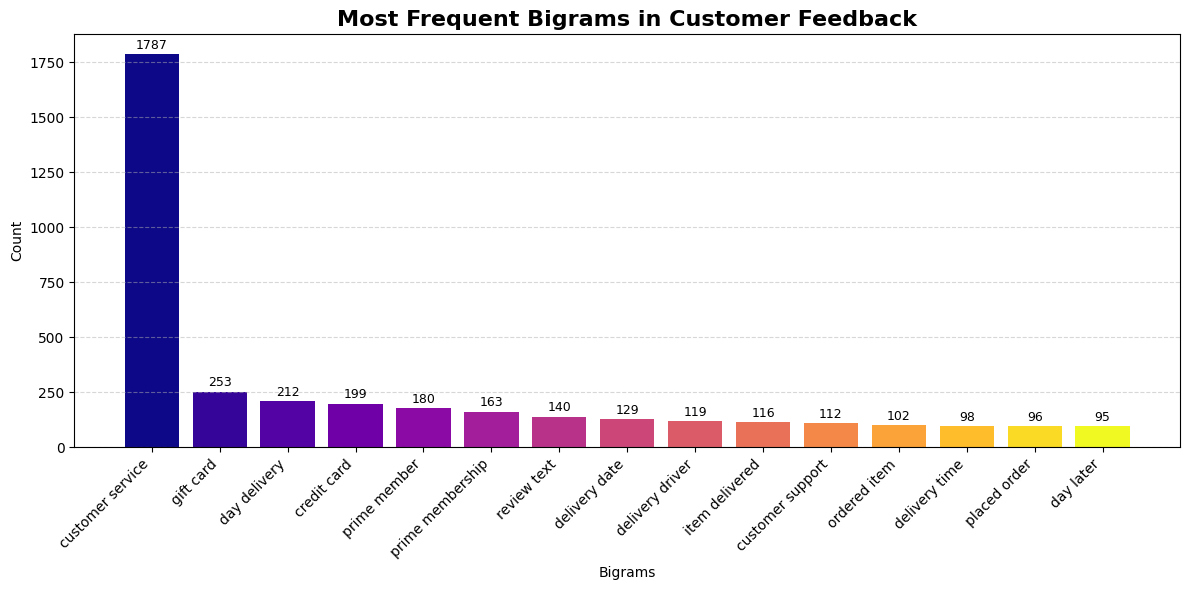

In [127]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,6))

colors = plt.cm.plasma(np.linspace(0, 1, len(bigram_df)))

bars = plt.bar(bigram_df['Bigram'], bigram_df['Count'], color=colors)

# Add labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval),
             ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=45, ha='right')
plt.title("Most Frequent Bigrams in Customer Feedback", fontsize=16, fontweight='bold')
plt.xlabel("Bigrams")
plt.ylabel("Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Sentiment Analysis of Customer Reviews

In [128]:
def get_sentiment_label(score):

    if score > 0:
        return 'Positive'

    elif score < 0:
        return 'Negative'

    else:
        return 'Neutral'


df['sentiment_score'] = df['Review Text'].apply(
    lambda text: TextBlob(str(text)).sentiment.polarity
)

df['sentiment_label'] = df['sentiment_score'].apply(
    get_sentiment_label
)

In [129]:
import plotly.express as px

# Count sentiments
sentiment_counts = df['sentiment_label'].value_counts().reset_index()
sentiment_counts.columns = ['Sentiment', 'Count']

fig = px.pie(
    sentiment_counts,
    names='Sentiment',
    values='Count',
    title='Overall Sentiment Distribution of Customer Feedback',  # improved title
    hole=0.4,
    color='Sentiment',  # add this
    color_discrete_map={  # meaningful colors
        'Positive': '#2ecc71',
        'Negative': '#e74c3c',
        'Neutral': '#f39c12'
    }
)

# Improve labels
fig.update_traces(textinfo='percent+label')

# Center title
fig.update_layout(title_x=0.5)

fig.show()



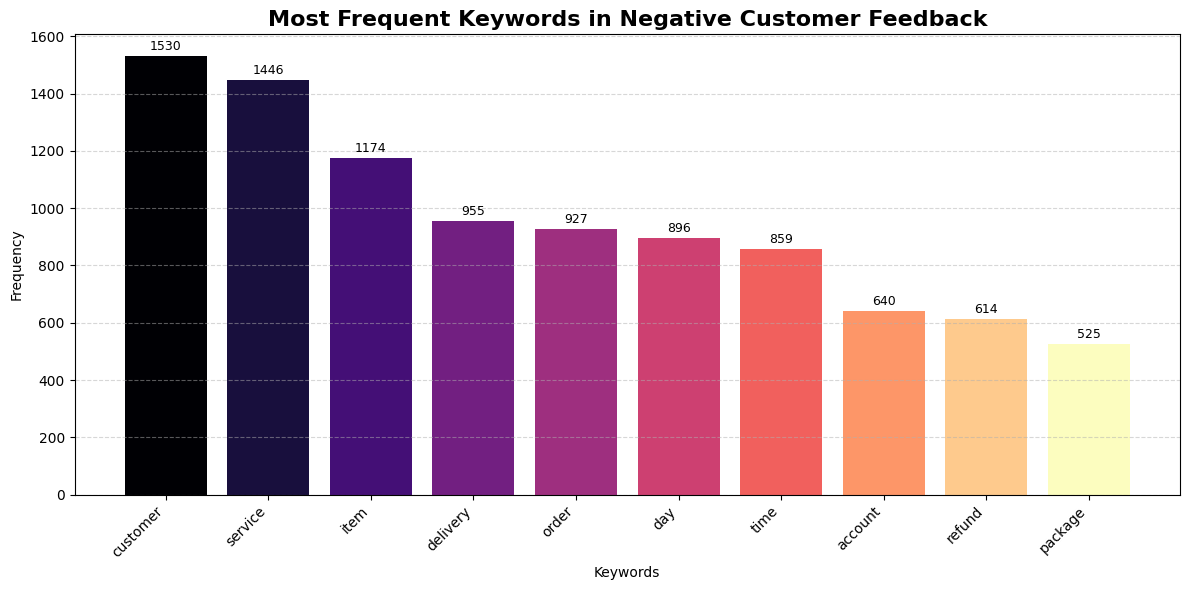

In [130]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))

colors = plt.cm.magma(np.linspace(0, 1, len(negative_keywords_df))) # Using a different colormap for distinction

bars = plt.bar(negative_keywords_df['Keyword'], negative_keywords_df['Frequency'], color=colors)

# Add labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval),
             ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=45, ha='right')
plt.title("Most Frequent Keywords in Negative Customer Feedback", fontsize=16, fontweight='bold')
plt.xlabel("Keywords")
plt.ylabel("Frequency")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()